In [46]:
# Install kaggle
!pip install kaggle
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')
# Create kaggle folder
!mkdir -p ~/.kaggle
# Copy kaggle.json from Drive
!cp /content/drive/MyDrive/kaggle/kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
# Download dataset
!kaggle datasets download -d ulnnproject/food-freshness-dataset
# Extract dataset
import zipfile
with zipfile.ZipFile("food-freshness-dataset.zip", "r") as zip_ref:
    zip_ref.extractall("/content/data")
# Show files
import os
print(os.listdir("/content/data"))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
cp: cannot stat '/content/drive/MyDrive/kaggle/kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Dataset URL: https://www.kaggle.com/datasets/ulnnproject/food-freshness-dataset
License(s): apache-2.0
food-freshness-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)
['Dataset']


In [47]:
import os
import shutil

# The root directory where 'Fresh' and 'Rotten' folders are located
dataset_base_path = "/content/data/Dataset"

# Define the class folders (Fresh and Rotten)
class_folders = ['Fresh', 'Rotten']

print(f"Flattening directory structure under: {dataset_base_path}")

for class_folder in class_folders:
    class_path = os.path.join(dataset_base_path, class_folder)
    if os.path.exists(class_path) and os.path.isdir(class_path):
        print(f"Processing class folder: {class_path}")
        # Iterate over subdirectories within the class folder (e.g., FreshApple, FreshBanana)
        for sub_dir_name in os.listdir(class_path):
            sub_dir_path = os.path.join(class_path, sub_dir_name)
            if os.path.isdir(sub_dir_path): # Ensure it's a directory
                print(f"  Moving images from subdirectory: {sub_dir_path}")
                # Move all image files from the subdirectory to the class folder
                for img_name in os.listdir(sub_dir_path):
                    # Check for common image file extensions
                    if img_name.lower().endswith(('.jpg', '.jpeg', '.png', '.gif', '.bmp', '.tiff')):
                        src_path = os.path.join(sub_dir_path, img_name)
                        dst_path = os.path.join(class_path, img_name)
                        # Only move if the destination doesn't already have a file of the same name
                        if not os.path.exists(dst_path):
                            shutil.move(src_path, dst_path)
                        else:
                            print(f"    Warning: Skipping move of {img_name} to {class_path} as file with same name already exists. Consider renaming if duplicates are an issue.")
                # After moving files, remove the now empty subdirectory
                try:
                    if not os.listdir(sub_dir_path): # Only remove if truly empty
                        os.rmdir(sub_dir_path)
                        print(f"  Removed empty subdirectory: {sub_dir_path}")
                    else:
                        print(f"  Subdirectory {sub_dir_path} is not empty after move, skipping removal.")
                except OSError as e:
                    print(f"  Error removing directory {sub_dir_path}: {e}")
            else:
                print(f"  Skipping non-directory entry in {class_path}: {sub_dir_name}")
    else:
        print(f"Class folder not found or not a directory: {class_path}. Please check your dataset extraction.")

print("Directory structure flattening complete. You can now re-run the cell defining `train_data` and `validation_data` (cell 28571373).")

Streaming output truncated to the last 5000 lines.
  Subdirectory /content/data/Dataset/Rotten/RottenCucumber is not empty after move, skipping removal.
  Skipping non-directory entry in /content/data/Dataset/Rotten: c_r121.png
  Skipping non-directory entry in /content/data/Dataset/Rotten: c_r010.png
  Skipping non-directory entry in /content/data/Dataset/Rotten: saltandpepper_Screen Shot 2018-06-12 at 11.32.46 PM.png
  Skipping non-directory entry in /content/data/Dataset/Rotten: rottenPepper (220).jpg
  Skipping non-directory entry in /content/data/Dataset/Rotten: vertical_flip_Screen Shot 2018-06-12 at 9.00.31 PM.png
  Skipping non-directory entry in /content/data/Dataset/Rotten: rottenPotato (271).jpg
  Skipping non-directory entry in /content/data/Dataset/Rotten: b_r230.png
  Skipping non-directory entry in /content/data/Dataset/Rotten: rottenPotato (164).jpg
  Skipping non-directory entry in /content/data/Dataset/Rotten: b_r649.png
  Skipping non-directory entry in /content/data

In [48]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os
import cv2

from sklearn.model_selection import train_test_split

from sklearn.svm import SVC

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

In [49]:
IMG_SIZE = 16

In [50]:
data = []

labels = []

dataset_path = "/content/data/Dataset"

In [51]:
fresh_path = os.path.join(dataset_path, "Fresh")

for sub_dir_name in os.listdir(fresh_path):
    sub_dir_path = os.path.join(fresh_path, sub_dir_name)
    if os.path.isdir(sub_dir_path):
        for img_name in os.listdir(sub_dir_path):
            img_path = os.path.join(sub_dir_path, img_name)
            if os.path.isfile(img_path):
                img = cv2.imread(img_path)
                if img is not None:
                    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
                    data.append(img)
                    labels.append(0)
                else:
                    print(f"Warning: Could not read image file: {img_path}")
            else:
                print(f"Skipping non-file entry inside subdirectory: {img_path}")
    else:
        print(f"Skipping non-directory entry in fresh_path: {sub_dir_path}")

rotten_path = os.path.join(dataset_path, "Rotten")

for sub_dir_name in os.listdir(rotten_path):
    sub_dir_path = os.path.join(rotten_path, sub_dir_name)
    if os.path.isdir(sub_dir_path):
        for img_name in os.listdir(sub_dir_path):
            img_path = os.path.join(sub_dir_path, img_name)
            if os.path.isfile(img_path):
                img = cv2.imread(img_path)
                if img is not None:
                    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
                    data.append(img)
                    labels.append(1)
                else:
                    print(f"Warning: Could not read image file: {img_path}")
            else:
                print(f"Skipping non-file entry inside subdirectory: {img_path}")
    else:
        print(f"Skipping non-directory entry in rotten_path: {sub_dir_path}")

Streaming output truncated to the last 5000 lines.
Skipping non-directory entry in rotten_path: /content/data/Dataset/Rotten/rotated_by_15_Screen Shot 2018-06-07 at 2.52.09 PM.png
Skipping non-directory entry in rotten_path: /content/data/Dataset/Rotten/WhatsApp Image 2020-11-07 at 11.35.36 PM(1).jpg_0_3413.jpg
Skipping non-directory entry in rotten_path: /content/data/Dataset/Rotten/c_r022.png
Skipping non-directory entry in rotten_path: /content/data/Dataset/Rotten/rottenBanana (108).jpg
Skipping non-directory entry in rotten_path: /content/data/Dataset/Rotten/rotated_by_60_Screen Shot 2018-06-12 at 11.23.33 PM.png
Skipping non-directory entry in rotten_path: /content/data/Dataset/Rotten/o_r186.png
Skipping non-directory entry in rotten_path: /content/data/Dataset/Rotten/rotated_by_75_Screen Shot 2018-06-07 at 2.19.15 PM.png
Skipping non-directory entry in rotten_path: /content/data/Dataset/Rotten/rotated_by_45_Screen Shot 2018-06-12 at 11.43.49 PM.png
Skipping non-directory entry in

In [52]:
X = np.array(data)

y = np.array(labels)

In [53]:
#normalisation
X = X / 255.0

In [54]:
#FLATTEN IMAGES
X = X.reshape(X.shape[0], -1)

In [55]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [56]:
#SVM
svm_model = SVC()

svm_model.fit(X_train, y_train)

svm_predictions = svm_model.predict(X_test)

svm_accuracy = accuracy_score(y_test, svm_predictions)

print("SVM Accuracy:", svm_accuracy)

SVM Accuracy: 0.8711531720995443


**SVM**

Saving Screen Shot 2018-06-07 at 2.56.47 PM.png to Screen Shot 2018-06-07 at 2.56.47 PM (13).png


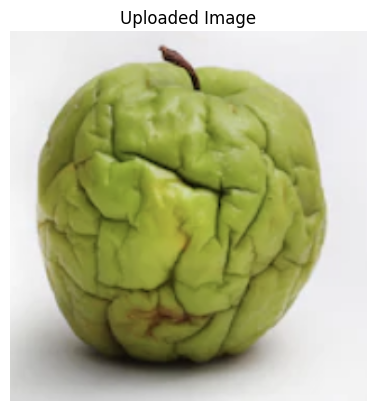

Prediction: Rotten


In [57]:
from google.colab import files
import cv2
import numpy as np
import matplotlib.pyplot as plt

uploaded = files.upload()

image_path = list(uploaded.keys())[0]

img = cv2.imread(image_path)

if img is None:
    print("Image could not be loaded!")

else:

    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title("Uploaded Image")
    plt.axis("off")
    plt.show()

    resized_img = cv2.resize(img, (16,16))

    normalized_img = resized_img / 255.0

    flattened_img = normalized_img.reshape(1, -1)

    prediction = svm_model.predict(flattened_img)

    if prediction[0] == 0:
        print("Prediction: Fresh")
    else:
        print("Prediction: Rotten")